In [1]:
import pathlib

import itertools
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import pickle
import pingouin as pg


import STX3KO_analyses as stx
from STX3KO_analyses import utilities as u
from STX3KO_analyses.run_sig_fields_spatial_perm import filter_fields


ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice

plt.rcParams['pdf.fonttype']=42
plt.rcParams['font.family'] ='sans-serif'
plt.rcParams['font.serif'] = 'Arial'


%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
figdir = pathlib.Path('/mnt/BigDisk/fig_scratch/stx3/fig3_place_fields')
figdir.mkdir(exist_ok=True, parents=True)

In [3]:
with open('/home/mplitt/shuffle_pkls/dense_place_field_spatial_shuffle_F_dff.pkl','rb') as file:
    shuff_results = pickle.load(file)
            

# number of fields per cell 

In [4]:
df = {'cre': [], 'mouse': [], 'day': [], 'nov': [], 'n_fields': []}
for key, mice in zip(('ctrl', 'ko'),(ctrl_mice, ko_mice)):
    for mouse in mice:
        for day in range(6):
            for nov in ( 'fam', 'nov'):

                rising_edges = shuff_results[mouse][day][nov]['rising_edges']
                falling_edges = shuff_results[mouse][day][nov]['falling_edges']

                width = falling_edges[:,1]-rising_edges[:,1]
                mask = (width>1) * (width<25) 
                n_fields = np.bincount(rising_edges[mask,0])
                

                # widths = shuff_resu
        
                n_fields = n_fields[n_fields>0]

                for n in n_fields:
                    df['cre'].append(key)
                    df['mouse'].append(mouse)
                    df['day'].append(day)
                    df['nov'].append(nov)
                    df['n_fields'].append(n)

df = pd.DataFrame.from_dict(df)

In [5]:
df.groupby("mouse")["cre"].first()

mouse
4467331.1    ctrl
4467331.2    ctrl
4467332.1    ctrl
4467332.2    ctrl
4467333.1    ctrl
4467975.1      ko
4467975.2      ko
4467975.3      ko
4467975.4      ko
4467975.5      ko
Cre7           ko
Cre9           ko
mCherry6     ctrl
mCherry7     ctrl
mCherry8     ctrl
mCherry9     ctrl
Name: cre, dtype: object

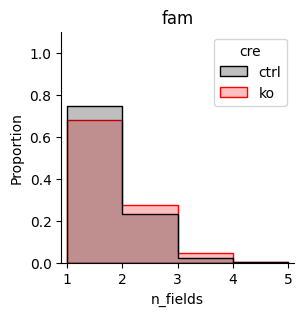

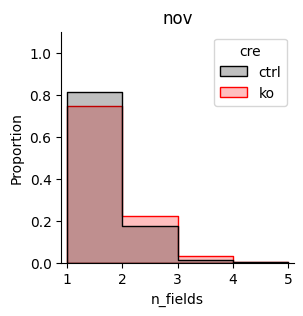

In [6]:
for nov in ('fam', 'nov'):

    fig,ax = plt.subplots(figsize=[3,3])
    sns.histplot(data=df.loc[df['nov']==nov], x='n_fields', hue='cre', cumulative=False, hue_order=('ctrl', 'ko'), palette=['black', 'red'],
                binwidth=1, fill=True, element = 'step', stat='proportion', common_norm=False, ax=ax)
    ax.set_ylim([0,1.1])
    ax.set_xlim([.9,5.1])

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_title(nov)

    fig.savefig(figdir / f'fields_per_cell_hist_{nov}.pdf', bbox_inches='tight')


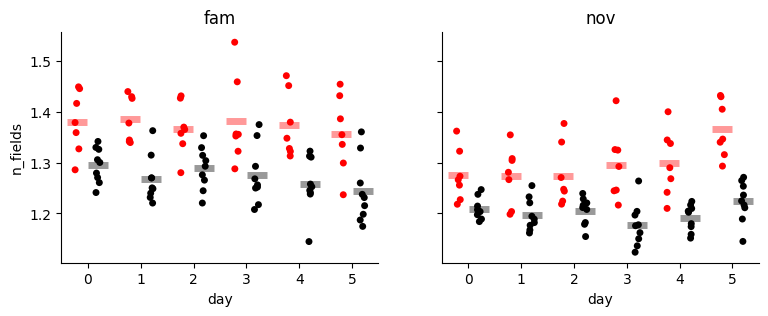

In [7]:
df_mu = df.groupby(['mouse','day','cre','nov'])['n_fields'].mean().reset_index()
df_mu.head()
fig,ax = plt.subplots(1,2, figsize=[9,3], sharey = True)
for i, nov in enumerate(('fam','nov')):
    sns.stripplot(data=df_mu.loc[df_mu['nov']==nov,:],
                x='day',
                y='n_fields',
                hue='cre', 
                hue_order=('ko', 'ctrl'), 
                palette=['red', 'black'],
                dodge=True,
                ax=ax[i],
                legend=False)
    


    sns.pointplot(data=df_mu.loc[df_mu['nov']==nov,:],
              x='day',
              y='n_fields',
              errorbar=None,
              hue='cre',
              hue_order = ['ko', 'ctrl'],
              dodge = .4,
              palette = ['red','black'],
              ax=ax[i],
              linestyles="none",
              marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=.4,
              )
    ax[i].set_title(nov)

for a in ax.flatten():
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)

fig.savefig( figdir / 'num_fields_per_day.pdf', bbox_inches='tight')


In [8]:

df['cre'] = df["cre"].astype("category")
df["mouse"] = df["mouse"].astype("category")
df["day"] = df["day"].astype("category")
df["nov"] = df["nov"].astype("category")
df["rank_n_fields"] = df["n_fields"].rank()
                   

In [9]:
import statsmodels.formula.api as smf
# Fit a mixed model on ranks
model = smf.mixedlm("rank_n_fields ~ cre * day * nov", df, groups=df["mouse"])
result = model.fit()
print(result.summary())

                       Mixed Linear Model Regression Results
Model:                    MixedLM         Dependent Variable:         rank_n_fields 
No. Observations:         129861          Method:                     REML          
No. Groups:               16              Scale:                      790486814.7732
Min. group size:          2565            Log-Likelihood:             -1514419.1312 
Max. group size:          12680           Converged:                  Yes           
Mean group size:          8116.3                                                    
------------------------------------------------------------------------------------
                                 Coef.    Std.Err.    z    P>|z|   [0.025    0.975] 
------------------------------------------------------------------------------------
Intercept                       65881.018  708.257  93.019 0.000 64492.860 67269.177
cre[T.ko]                        3989.063 1081.993   3.687 0.000  1868.395  6109.732
day[

In [10]:
result.fe_params['cre[T.ko]']

np.float64(3989.0634357832523)

In [ ]:
import joblib
def run_model(df_perm, all_mice, ctrl_mice):

    genotype_map = {}
    for mouse in all_mice:
        genotype_map[mouse] = "ko"
    for mouse in ctrl_mice:
        genotype_map[mouse] = "ctrl"
    
    
    df_perm["cre"] = df_perm["mouse"].map(genotype_map)
    df_perm["cre"] = df_perm["cre"].astype("category")

    md_perm = smf.mixedlm("rank_n_fields ~ cre * day * nov", df_perm, groups=df_perm["mouse"])
    try:
        res_perm = md_perm.fit()
        return res_perm.fe_params["cre[T.ko]"]
    except:
        return np.nan  # skip failed fits (rare)



shuff_coefs = np.array(joblib.Parallel(n_jobs=16)(joblib.delayed(run_model)(df.copy(), ctrl_mice+ko_mice, comb) for i, comb in enumerate(itertools.combinations(ctrl_mice+ko_mice,len(ctrl_mice))) if i <12000))


In [ ]:
(result.fe_params['cre[T.ko]'] < shuff_coefs).sum()/float(shuff_coefs.shape[0])

np.float64(0.015625)

In [6]:
res_fam = pg.pairwise_tests(data=df.loc[df['nov']=='fam',:],
                        dv='n_fields',
                        within=['day'],
                        subject='mouse',
                        between='cre',
                        padjust='holm',
                        parametric=False, within_first=False,
                        )

res_nov = pg.pairwise_tests(data=df.loc[df['nov']=='nov',:],
                        dv='n_fields',
                        within=['day'],
                        subject='mouse',
                        between='cre',
                        padjust='holm',
                        parametric=False, within_first=False,
                        )

In [7]:
res_fam.iloc[0]

Contrast             cre
cre                    -
A                   ctrl
B                     ko
Paired             False
Parametric         False
U-val                3.0
W-val                NaN
alternative    two-sided
p-unc           0.001224
p-corr               NaN
p-adjust             NaN
hedges         -2.063187
Name: 0, dtype: object

In [8]:
res_nov.iloc[0]

Contrast             cre
cre                    -
A                   ctrl
B                     ko
Paired             False
Parametric         False
U-val                1.0
W-val                NaN
alternative    two-sided
p-unc            0.00035
p-corr               NaN
p-adjust             NaN
hedges         -2.427123
Name: 0, dtype: object

In [11]:
res = pg.pairwise_tests(data=df,
                        dv='n_fields',
                        within=['day'],
                        subject='mouse',
                        between='cre',
                        padjust='holm',
                        parametric=False, within_first=False,
                        )


In [12]:
res

,Contrast,cre,A,B,Paired,Parametric,U-val,W-val,alternative,p-unc,p-corr,p-adjust,hedges
0,cre,-,ctrl,ko,False,False,1.0,NaN,two-sided,0.000350,NaN,NaN,-2.509231
1,day,-,0,1,True,False,NaN,46.0,two-sided,0.274445,1.00000,holm,0.178497
2,day,-,0,2,True,False,NaN,43.0,two-sided,0.211426,1.00000,holm,0.140156
3,day,-,0,3,True,False,NaN,42.0,two-sided,0.192810,1.00000,holm,0.164964
4,day,-,0,4,True,False,NaN,41.0,two-sided,0.175354,1.00000,holm,0.222774
5,day,-,0,5,True,False,NaN,62.0,two-sided,0.781952,1.00000,holm,0.063574
6,day,-,1,2,True,False,NaN,58.0,two-sided,0.632172,1.00000,holm,-0.055211
7,day,-,1,3,True,False,NaN,62.0,two-sided,0.781952,1.00000,holm,0.008881
8,day,-,1,4,True,False,NaN,65.0,two-sided,0.899933,1.00000,holm,0.051358
9,day,-,1,5,True,False,NaN,38.0,two-sided,0.129730,1.00000,holm,-0.088867


# field width 

In [10]:
df = {'cre': [], 'mouse': [], 'day': [], 'nov': [], 'width': []}
for key, mice in zip(('ctrl', 'ko'),(ctrl_mice, ko_mice)):
    for mouse in mice:
        for day in range(6):
            for nov in ('fam','nov'):
                rising_edges = shuff_results[mouse][day][nov]['rising_edges']
                falling_edges = shuff_results[mouse][day][nov]['falling_edges']
                widths = shuff_results[mouse][day][nov]['field_widths']
                
                mask = (widths>1) * (widths<25) * (rising_edges[:,1]>0) * (falling_edges[:,1]<29)
                widths = widths[mask]
                

                for w in widths:
                    df['cre'].append(key)
                    df['mouse'].append(mouse)
                    df['day'].append(day)
                    df['nov'].append(nov)
             
                    df['width'].append(w*10)
df = pd.DataFrame(df)

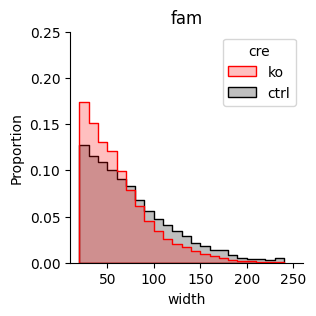

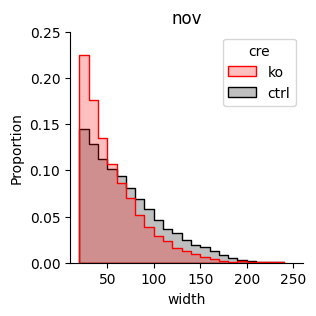

In [11]:
for nov in ('fam', 'nov'):
    fig,ax = plt.subplots(figsize=[3,3])
    sns.histplot(data=df.loc[df['nov']==nov,:], 
                x='width', 
                hue='cre', 
                cumulative=False, 
                hue_order=('ko', 'ctrl'), 
                palette=['red', 'black'],
                binwidth=10, 
                fill=True, element = 'step', stat='proportion', common_norm=False, ax=ax)
    # ax.set_ylim([0,1.1])
    ax.set_xlim([10,260])
    ax.set_ylim([0,.25])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_title(nov)
    fig.savefig(figdir / f'field_widths_hist_{nov}.pdf', bbox_inches='tight')


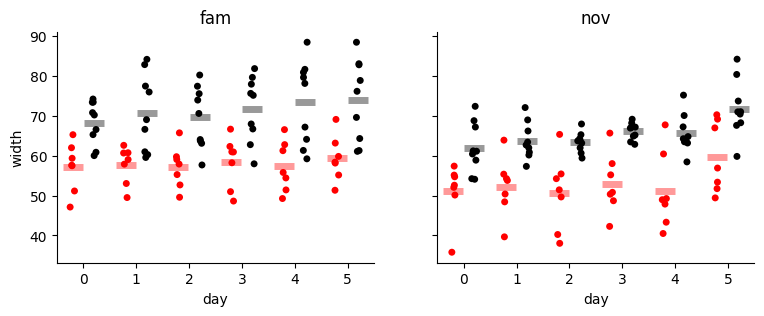

In [12]:
df_mu = df.groupby(['mouse','day','cre','nov'])['width'].mean().reset_index()
df_mu.head()
fig,ax = plt.subplots(1,2, figsize=[9,3], sharey=True)
for i, nov in enumerate(('fam','nov')):
    ax[i] = sns.stripplot(data=df_mu.loc[df_mu['nov']==nov,:],
                x='day',
                y='width',
                hue='cre', 
                hue_order=('ko', 'ctrl'), 
                palette=['red', 'black'],
                dodge=True,
                ax=ax[i],
                legend=False)
    
    sns.pointplot(data=df_mu.loc[df_mu['nov']==nov,:],
              x='day',
              y='width',
              errorbar=None,
              hue='cre',
              hue_order = ['ko', 'ctrl'],
              dodge = .4,
              palette = ['red','black'],
              ax=ax[i],
              linestyles="none",
              marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=.4,
              )
    ax[i].set_title(nov)
for a in ax.flatten():
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)

fig.savefig( figdir / 'field_widths_per_day.pdf', bbox_inches='tight')

In [13]:
res_fam = pg.pairwise_tests(data=df.loc[df['nov']=='fam',:],
                        dv='width',
                        within=['day'],
                        subject='mouse',
                        between='cre',
                        padjust='holm',
                        parametric=False, within_first=False,
                        )

res_nov = pg.pairwise_tests(data=df.loc[df['nov']=='nov',:],
                        dv='width',
                        within=['day'],
                        subject='mouse',
                        between='cre',
                        padjust='holm',
                        parametric=False, within_first=False,
                        )

In [14]:
res_fam.iloc[0]

Contrast             cre
cre                    -
A                   ctrl
B                     ko
Paired             False
Parametric         False
U-val               59.0
W-val                NaN
alternative    two-sided
p-unc           0.002098
p-corr               NaN
p-adjust             NaN
hedges          1.818436
Name: 0, dtype: object

In [15]:
res_nov.iloc[0]

Contrast             cre
cre                    -
A                   ctrl
B                     ko
Paired             False
Parametric         False
U-val               60.0
W-val                NaN
alternative    two-sided
p-unc           0.001224
p-corr               NaN
p-adjust             NaN
hedges          2.200151
Name: 0, dtype: object

## permutation test

In [83]:
perm_res = run_perm_test(df, ko_mice, ctrl_mice, 'width')

0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000


In [89]:
for nov in ('fam', 'nov'):
    x = df.loc[(df['nov']==nov) & (df['cre']=='ko'),'width']
    y = df.loc[(df['nov']==nov) & (df['cre']=='ctrl'),'width']
    u = sp.stats.mannwhitneyu(
        x,y,
        alternative='two-sided'
    ).statistic

    roc = u/x.shape[0]/y.shape[0]

    p = np.sum(np.array(perm_res[nov])<=roc)/len(perm_res[nov])
    print(f'{nov}: U={u}, p={p}')

fam: U=321942323.0, p=0.0006118881118881119
nov: U=186499447.0, p=0.0007867132867132868
